# 第十七章：變分自編碼器 (Variational Autoencoder)

本 notebook 實作 Kingma & Welling 2013 年論文《Auto-Encoding Variational Bayes》中的變分自編碼器。

**核心公式**：
$$\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))$$

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import matplotlib.pyplot as plt

# 設定隨機種子
torch.manual_seed(42)
np.random.seed(42)

# 設定設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch 版本: {torch.__version__}")
print(f"使用設備: {device}")

PyTorch 版本: 2.9.1
使用設備: cpu


## 1. VAE 核心模組

VAE 由三個部分組成：
1. **編碼器**：$q_\phi(z|x)$ - 將輸入映射到潛在分布
2. **重參數化**：$z = \mu + \sigma \odot \epsilon$ - 使採樣可微分
3. **解碼器**：$p_\theta(x|z)$ - 從潛在向量重建輸入

In [2]:
class VAE(nn.Module):
    """
    變分自編碼器 (Variational Autoencoder)
    
    架構：
    x → Encoder → (μ, log σ²) → 重參數化 → z → Decoder → x̂
    """
    
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        
        self.input_dim = input_dim
        self.latent_dim = latent_dim
        
        # 編碼器：x → hidden → (μ, log σ²)
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU()
        )
        
        # 潛在分布參數
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_logvar = nn.Linear(hidden_dim, latent_dim)
        
        # 解碼器：z → hidden → x̂
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, input_dim),
            nn.Sigmoid()  # 輸出範圍 [0, 1]
        )
        
    def encode(self, x):
        """
        編碼：x → (μ, log σ²)
        
        回傳潛在分布的參數，而非確定性向量
        """
        h = self.encoder(x)
        mu = self.fc_mu(h)
        log_var = self.fc_logvar(h)
        return mu, log_var
    
    def reparameterize(self, mu, log_var):
        """
        重參數化技巧
        
        z = μ + σ ⊙ ε, 其中 ε ~ N(0, I)
        
        這使得採樣操作變得可微分：
        - 隨機性來自 ε（與參數無關）
        - z 對 μ 和 σ 是確定性函數
        """
        std = torch.exp(0.5 * log_var)  # σ = exp(0.5 * log σ²)
        eps = torch.randn_like(std)      # ε ~ N(0, I)
        z = mu + std * eps               # 重參數化
        return z
    
    def decode(self, z):
        """
        解碼：z → x̂
        """
        return self.decoder(z)
    
    def forward(self, x):
        """
        完整前向傳播
        
        回傳：重建、均值、對數變異數
        """
        mu, log_var = self.encode(x)
        z = self.reparameterize(mu, log_var)
        x_recon = self.decode(z)
        return x_recon, mu, log_var
    
    def sample(self, num_samples):
        """
        從先驗分布採樣生成新樣本
        
        z ~ N(0, I) → Decoder → x
        """
        with torch.no_grad():
            z = torch.randn(num_samples, self.latent_dim).to(next(self.parameters()).device)
            samples = self.decode(z)
        return samples


# 建立 VAE
input_dim = 784  # 28x28 圖像
hidden_dim = 400
latent_dim = 20

vae = VAE(input_dim, hidden_dim, latent_dim).to(device)

print(f"VAE 架構:")
print(f"  輸入維度: {input_dim}")
print(f"  隱藏維度: {hidden_dim}")
print(f"  潛在維度: {latent_dim}")
print(f"  參數數量: {sum(p.numel() for p in vae.parameters()):,}")

VAE 架構:
  輸入維度: 784
  隱藏維度: 400
  潛在維度: 20
  參數數量: 973,624


## 2. VAE 損失函數

VAE 損失 = 重建損失 + KL 散度

$$\mathcal{L} = -\mathbb{E}_{q(z|x)}[\log p(x|z)] + D_{KL}(q(z|x) \| p(z))$$

In [3]:
def vae_loss(x, x_recon, mu, log_var, beta=1.0):
    """
    VAE 損失函數
    
    參數:
        x: 原始輸入 [batch, input_dim]
        x_recon: 重建輸出 [batch, input_dim]
        mu: 潛在分布均值 [batch, latent_dim]
        log_var: 潛在分布對數變異數 [batch, latent_dim]
        beta: KL 散度權重（β-VAE）
    
    回傳:
        total_loss, recon_loss, kl_loss
    """
    batch_size = x.size(0)
    
    # 重建損失（Binary Cross Entropy）
    # 假設 p(x|z) 是伯努利分布
    recon_loss = F.binary_cross_entropy(x_recon, x, reduction='sum') / batch_size
    
    # KL 散度（閉式解）
    # KL(N(μ, σ²) || N(0, 1)) = -0.5 * Σ(1 + log σ² - μ² - σ²)
    kl_loss = -0.5 * torch.sum(1 + log_var - mu.pow(2) - log_var.exp()) / batch_size
    
    # 總損失
    total_loss = recon_loss + beta * kl_loss
    
    return total_loss, recon_loss, kl_loss


# 測試損失函數
x_test = torch.rand(32, input_dim).to(device)
x_recon, mu, log_var = vae(x_test)
total, recon, kl = vae_loss(x_test, x_recon, mu, log_var)

print(f"測試損失計算:")
print(f"  總損失: {total.item():.4f}")
print(f"  重建損失: {recon.item():.4f}")
print(f"  KL 散度: {kl.item():.4f}")

測試損失計算:
  總損失: 544.4865
  重建損失: 544.4335
  KL 散度: 0.0529


## 3. 生成合成資料集

為了快速演示，我們生成一個簡單的合成資料集。

訓練資料: 5000 樣本
測試資料: 1000 樣本


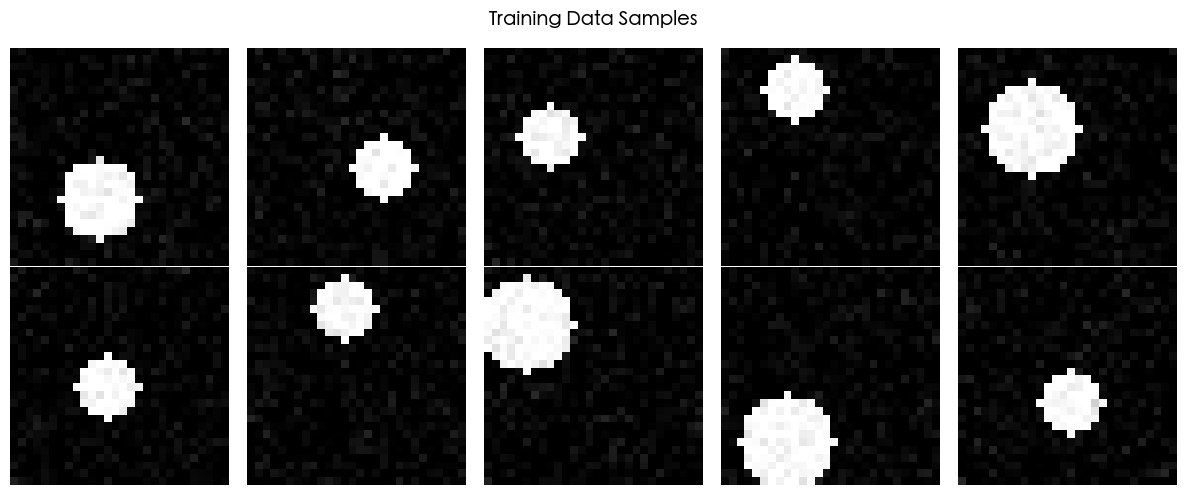

已儲存: training_samples.png


In [4]:
def generate_synthetic_dataset(num_samples=5000, img_size=28):
    """
    生成合成資料集：不同位置和大小的圓形
    """
    data = []
    
    for _ in range(num_samples):
        img = np.zeros((img_size, img_size))
        
        # 隨機圓心和半徑
        cx = np.random.randint(5, img_size - 5)
        cy = np.random.randint(5, img_size - 5)
        radius = np.random.randint(3, 8)
        
        # 繪製圓形
        y, x = np.ogrid[:img_size, :img_size]
        mask = (x - cx)**2 + (y - cy)**2 <= radius**2
        img[mask] = 1.0
        
        # 添加噪聲
        img += np.random.randn(img_size, img_size) * 0.05
        img = np.clip(img, 0, 1)
        
        data.append(img.flatten())
    
    return np.array(data, dtype=np.float32)


# 生成資料
X_train = generate_synthetic_dataset(5000)
X_test = generate_synthetic_dataset(1000)

# 轉換為 PyTorch 張量
train_data = torch.FloatTensor(X_train)
test_data = torch.FloatTensor(X_test)

# 建立資料載入器
train_loader = DataLoader(TensorDataset(train_data), batch_size=128, shuffle=True)
test_loader = DataLoader(TensorDataset(test_data), batch_size=128, shuffle=False)

print(f"訓練資料: {len(train_data)} 樣本")
print(f"測試資料: {len(test_data)} 樣本")

# 視覺化樣本
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28, 28), cmap='gray')
    ax.axis('off')
plt.suptitle('Training Data Samples', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('training_samples.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("已儲存: training_samples.png")

## 4. 訓練 VAE

In [5]:
def train_vae(model, train_loader, optimizer, epochs, beta=1.0):
    """
    訓練 VAE
    """
    model.train()
    history = {'total': [], 'recon': [], 'kl': []}
    
    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0
        
        for batch_idx, (data,) in enumerate(train_loader):
            data = data.to(device)
            
            optimizer.zero_grad()
            
            # 前向傳播
            x_recon, mu, log_var = model(data)
            
            # 計算損失
            loss, recon, kl = vae_loss(data, x_recon, mu, log_var, beta)
            
            # 反向傳播
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
        
        # 記錄
        n_batches = len(train_loader)
        history['total'].append(total_loss / n_batches)
        history['recon'].append(total_recon / n_batches)
        history['kl'].append(total_kl / n_batches)
        
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch+1:3d} | "
                  f"Loss: {history['total'][-1]:.4f} | "
                  f"Recon: {history['recon'][-1]:.4f} | "
                  f"KL: {history['kl'][-1]:.4f}")
    
    return history


# 重新建立模型（較小的潛在維度以便視覺化）
vae = VAE(input_dim=784, hidden_dim=256, latent_dim=2).to(device)
optimizer = optim.Adam(vae.parameters(), lr=1e-3)

print("開始訓練 VAE...")
print("=" * 60)
history = train_vae(vae, train_loader, optimizer, epochs=30)
print("=" * 60)
print("訓練完成！")

開始訓練 VAE...
Epoch   5 | Loss: 176.1522 | Recon: 169.6789 | KL: 6.4733
Epoch  10 | Loss: 151.5320 | Recon: 145.0399 | KL: 6.4921
Epoch  15 | Loss: 143.9990 | Recon: 137.3641 | KL: 6.6349
Epoch  20 | Loss: 139.2400 | Recon: 132.4365 | KL: 6.8035
Epoch  25 | Loss: 136.1457 | Recon: 129.1513 | KL: 6.9944
Epoch  30 | Loss: 132.5934 | Recon: 125.5136 | KL: 7.0798
訓練完成！


## 5. 視覺化訓練過程

已儲存: training_curves.png


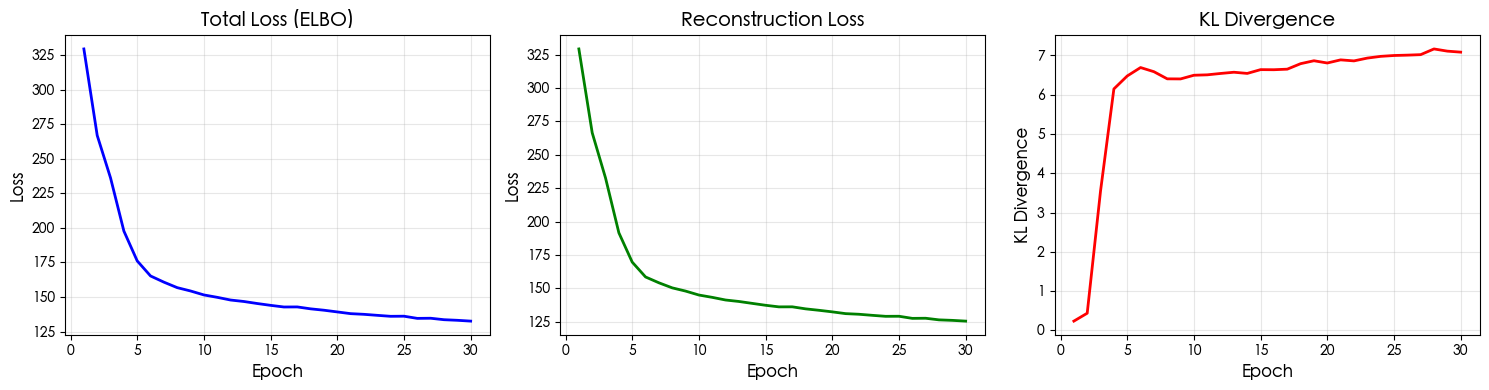

In [6]:
def plot_training_history(history, save_path=None):
    """繪製訓練歷史"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    epochs = range(1, len(history['total']) + 1)
    
    # 總損失
    axes[0].plot(epochs, history['total'], 'b-', linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Loss', fontsize=12)
    axes[0].set_title('Total Loss (ELBO)', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)
    
    # 重建損失
    axes[1].plot(epochs, history['recon'], 'g-', linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('Loss', fontsize=12)
    axes[1].set_title('Reconstruction Loss', fontsize=14, fontweight='bold')
    axes[1].grid(True, alpha=0.3)
    
    # KL 散度
    axes[2].plot(epochs, history['kl'], 'r-', linewidth=2)
    axes[2].set_xlabel('Epoch', fontsize=12)
    axes[2].set_ylabel('KL Divergence', fontsize=12)
    axes[2].set_title('KL Divergence', fontsize=14, fontweight='bold')
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


plot_training_history(history, save_path='training_curves.png')

## 6. 重建品質評估

已儲存: reconstruction.png


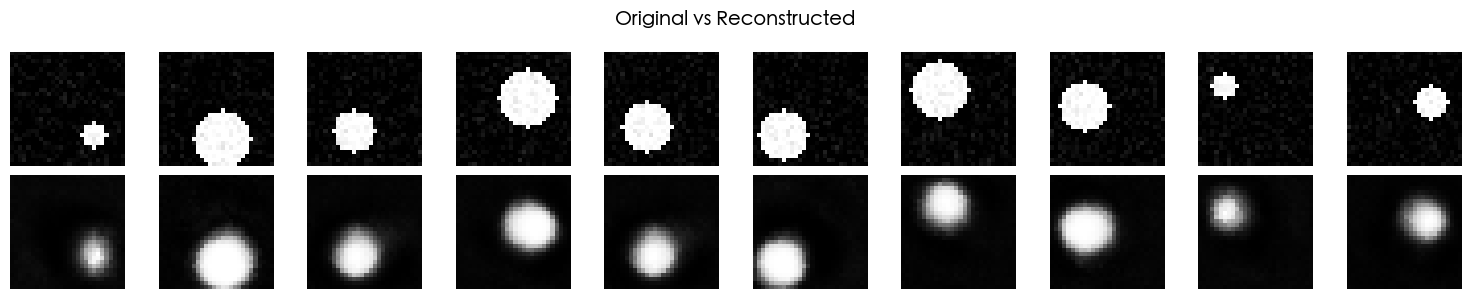

In [7]:
def visualize_reconstruction(model, data, num_samples=10, save_path=None):
    """視覺化原始圖像與重建圖像"""
    model.eval()
    
    with torch.no_grad():
        x = data[:num_samples].to(device)
        x_recon, _, _ = model(x)
    
    fig, axes = plt.subplots(2, num_samples, figsize=(num_samples * 1.5, 3))
    
    for i in range(num_samples):
        # 原始
        axes[0, i].imshow(x[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel('Original', fontsize=12)
        
        # 重建
        axes[1, i].imshow(x_recon[i].cpu().numpy().reshape(28, 28), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel('Reconstructed', fontsize=12)
    
    plt.suptitle('Original vs Reconstructed', fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


visualize_reconstruction(vae, test_data, save_path='reconstruction.png')

## 7. 潛在空間視覺化

已儲存: latent_space.png


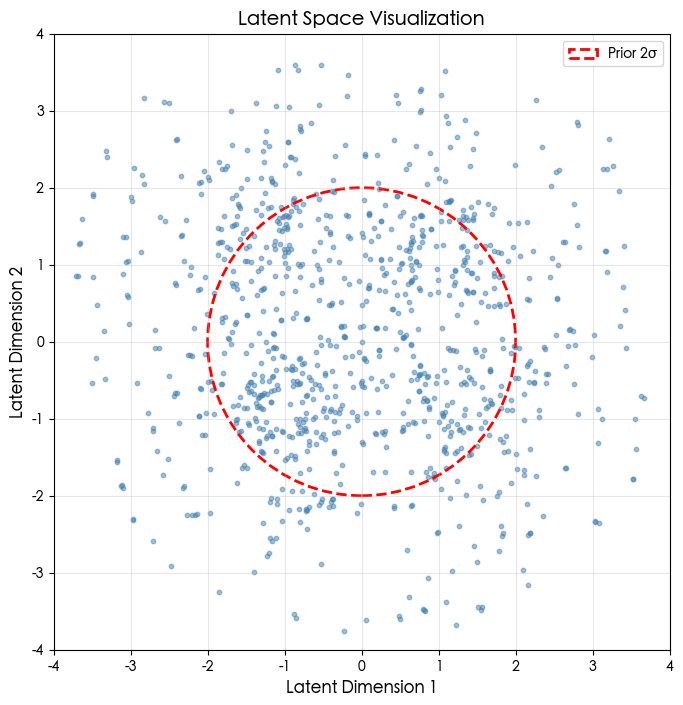

In [8]:
def visualize_latent_space(model, data, save_path=None):
    """視覺化 2D 潛在空間"""
    model.eval()
    
    with torch.no_grad():
        x = data.to(device)
        mu, log_var = model.encode(x)
        z = mu.cpu().numpy()  # 使用均值作為潛在表示
    
    fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(z[:, 0], z[:, 1], alpha=0.5, s=10, c='steelblue')
    
    ax.set_xlabel('Latent Dimension 1', fontsize=12)
    ax.set_ylabel('Latent Dimension 2', fontsize=12)
    ax.set_title('Latent Space Visualization', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.3)
    
    # 標示先驗分布範圍
    circle = plt.Circle((0, 0), 2, fill=False, color='red', 
                         linestyle='--', linewidth=2, label='Prior 2σ')
    ax.add_patch(circle)
    ax.legend()
    ax.set_aspect('equal')
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


visualize_latent_space(vae, test_data, save_path='latent_space.png')

## 8. 從先驗分布生成新樣本

已儲存: generated_samples.png


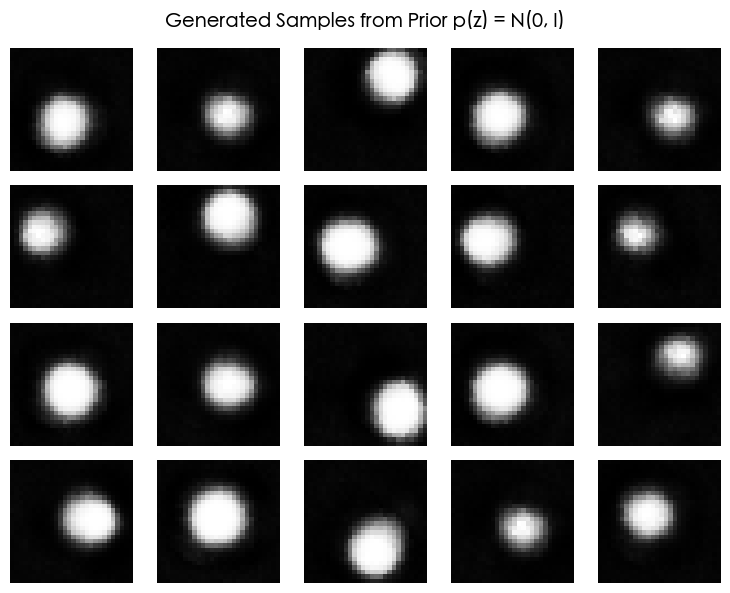

In [9]:
def generate_samples(model, num_samples=20, save_path=None):
    """從先驗分布生成新樣本"""
    model.eval()
    
    samples = model.sample(num_samples).cpu().numpy()
    
    rows = 4
    cols = num_samples // rows
    
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 1.5, rows * 1.5))
    
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
    
    plt.suptitle('Generated Samples from Prior p(z) = N(0, I)', 
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


generate_samples(vae, num_samples=20, save_path='generated_samples.png')

## 9. 潛在空間插值

已儲存: interpolation.png


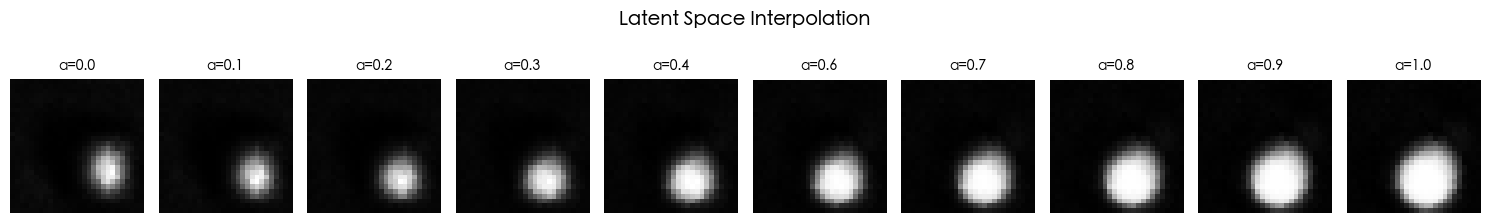

In [10]:
def interpolate_latent_space(model, x1, x2, steps=10, save_path=None):
    """在潛在空間中進行線性插值"""
    model.eval()
    
    with torch.no_grad():
        # 編碼兩個樣本
        mu1, _ = model.encode(x1.unsqueeze(0).to(device))
        mu2, _ = model.encode(x2.unsqueeze(0).to(device))
        
        # 線性插值
        interpolations = []
        for alpha in np.linspace(0, 1, steps):
            z = (1 - alpha) * mu1 + alpha * mu2
            x_interp = model.decode(z)
            interpolations.append(x_interp.cpu().numpy())
    
    # 視覺化
    fig, axes = plt.subplots(1, steps, figsize=(steps * 1.5, 2))
    
    for i, ax in enumerate(axes):
        ax.imshow(interpolations[i].reshape(28, 28), cmap='gray')
        ax.axis('off')
        ax.set_title(f'α={i/(steps-1):.1f}', fontsize=10)
    
    plt.suptitle('Latent Space Interpolation', fontsize=14, fontweight='bold', y=1.1)
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


# 選擇兩個不同的樣本
x1 = test_data[0]
x2 = test_data[50]

interpolate_latent_space(vae, x1, x2, steps=10, save_path='interpolation.png')

## 10. 潛在空間網格視覺化

已儲存: latent_grid.png


/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_98708/3545295427.py:31: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Heiti TC.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_98708/3545295427.py:31: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Heiti TC.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
/Users/joshhu/workspace/ilya_cht/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Heiti TC.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/joshhu/workspace/ilya_cht/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Heiti TC.
  fig.canvas.print_figure(bytes_io, **kw)


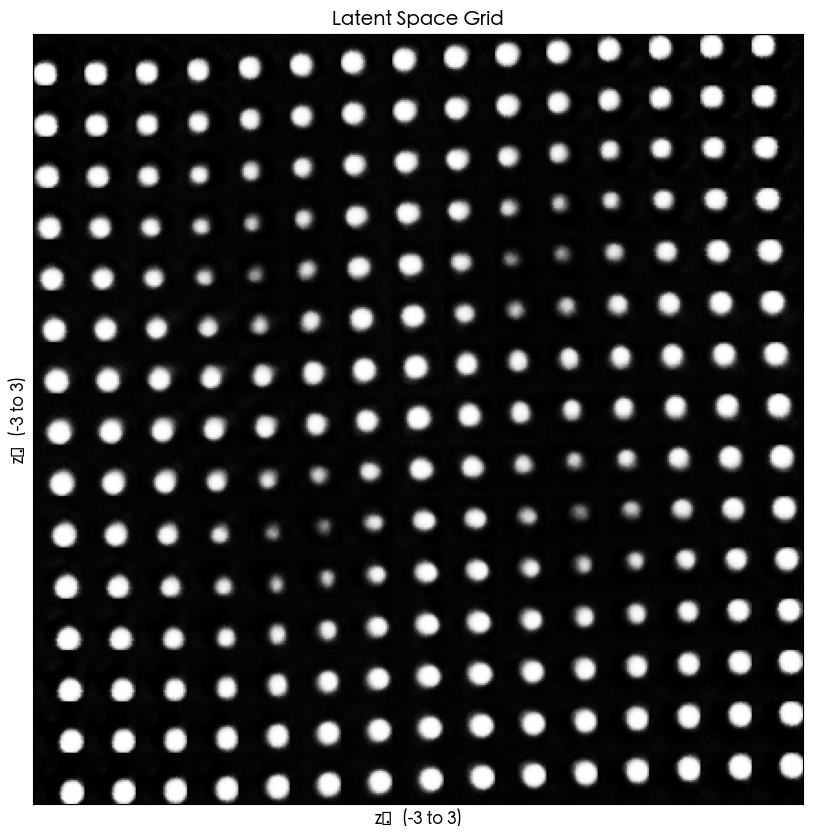

In [11]:
def visualize_latent_grid(model, n=15, latent_range=3, save_path=None):
    """
    在 2D 潛在空間上建立網格，解碼並視覺化
    """
    model.eval()
    
    # 建立網格
    z1 = np.linspace(-latent_range, latent_range, n)
    z2 = np.linspace(-latent_range, latent_range, n)
    
    # 生成圖像
    canvas = np.zeros((28 * n, 28 * n))
    
    with torch.no_grad():
        for i, y in enumerate(z2[::-1]):  # 反轉 y 軸
            for j, x in enumerate(z1):
                z = torch.FloatTensor([[x, y]]).to(device)
                sample = model.decode(z).cpu().numpy()
                canvas[i*28:(i+1)*28, j*28:(j+1)*28] = sample.reshape(28, 28)
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.imshow(canvas, cmap='gray')
    ax.set_xlabel(f'z₁ ({-latent_range} to {latent_range})', fontsize=12)
    ax.set_ylabel(f'z₂ ({-latent_range} to {latent_range})', fontsize=12)
    ax.set_title('Latent Space Grid', fontsize=14, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


visualize_latent_grid(vae, n=15, latent_range=3, save_path='latent_grid.png')

## 11. 重參數化技巧視覺化

已儲存: reparameterization.png


/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_98708/1397683619.py:46: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Heiti TC.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_98708/1397683619.py:46: UserWarning: Glyph 8321 (\N{SUBSCRIPT ONE}) missing from font(s) Heiti TC.
  plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')


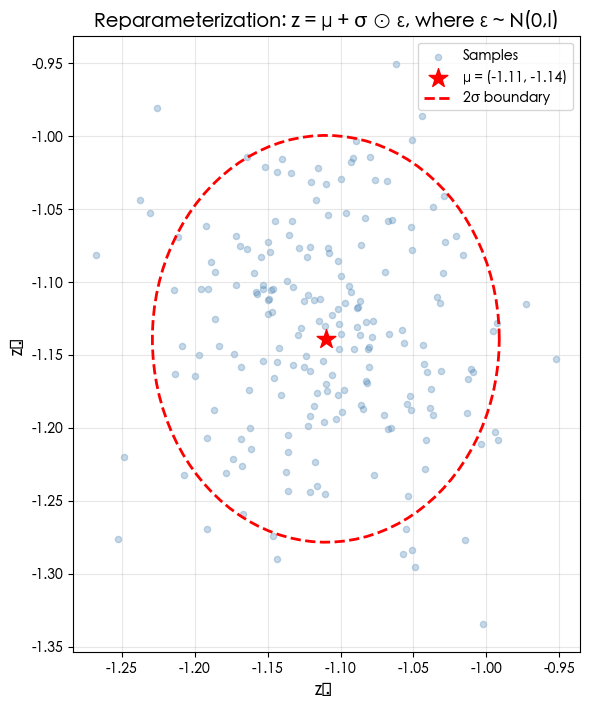

μ = [-1.1101191 -1.139001 ]
σ = [0.05947441 0.06973854]
樣本均值: [-1.1093963 -1.1350615]
樣本標準差: [0.0585629  0.07085276]


In [12]:
def visualize_reparameterization(model, x, num_samples=200, save_path=None):
    """
    視覺化重參數化技巧：從同一個 q(z|x) 多次採樣
    """
    model.eval()
    
    with torch.no_grad():
        x_input = x.unsqueeze(0).to(device)
        mu, log_var = model.encode(x_input)
        
        # 多次採樣
        z_samples = []
        for _ in range(num_samples):
            z = model.reparameterize(mu, log_var)
            z_samples.append(z.cpu().numpy())
        
        z_samples = np.array(z_samples).squeeze()
    
    # 計算標準差
    std = torch.exp(0.5 * log_var).cpu().numpy().squeeze()
    mu_np = mu.cpu().numpy().squeeze()
    
    # 視覺化
    fig, ax = plt.subplots(figsize=(10, 8))
    
    ax.scatter(z_samples[:, 0], z_samples[:, 1], alpha=0.3, s=20, 
               label='Samples', color='steelblue')
    ax.scatter(mu_np[0], mu_np[1], color='red', s=200, marker='*', 
               label=f'μ = ({mu_np[0]:.2f}, {mu_np[1]:.2f})', zorder=5)
    
    # 繪製橢圓（2σ）
    theta = np.linspace(0, 2*np.pi, 100)
    ellipse_x = mu_np[0] + 2 * std[0] * np.cos(theta)
    ellipse_y = mu_np[1] + 2 * std[1] * np.sin(theta)
    ax.plot(ellipse_x, ellipse_y, 'r--', linewidth=2, label='2σ boundary')
    
    ax.set_xlabel('z₁', fontsize=12)
    ax.set_ylabel('z₂', fontsize=12)
    ax.set_title('Reparameterization: z = μ + σ ⊙ ε, where ε ~ N(0,I)', 
                fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()
    
    print(f"μ = {mu_np}")
    print(f"σ = {std}")
    print(f"樣本均值: {z_samples.mean(axis=0)}")
    print(f"樣本標準差: {z_samples.std(axis=0)}")


visualize_reparameterization(vae, test_data[0], save_path='reparameterization.png')

## 12. β-VAE：解耦表示學習

In [13]:
def compare_beta_values(train_loader, betas=[0.1, 1.0, 4.0], epochs=20):
    """
    比較不同 β 值對 VAE 的影響
    """
    results = {}
    
    for beta in betas:
        print(f"\n訓練 β = {beta}...")
        
        # 建立新模型
        model = VAE(input_dim=784, hidden_dim=256, latent_dim=2).to(device)
        optimizer = optim.Adam(model.parameters(), lr=1e-3)
        
        # 訓練
        history = {'recon': [], 'kl': []}
        
        for epoch in range(epochs):
            total_recon = 0
            total_kl = 0
            
            for (data,) in train_loader:
                data = data.to(device)
                optimizer.zero_grad()
                
                x_recon, mu, log_var = model(data)
                loss, recon, kl = vae_loss(data, x_recon, mu, log_var, beta)
                
                loss.backward()
                optimizer.step()
                
                total_recon += recon.item()
                total_kl += kl.item()
            
            history['recon'].append(total_recon / len(train_loader))
            history['kl'].append(total_kl / len(train_loader))
        
        results[beta] = {'model': model, 'history': history}
        print(f"  最終 - Recon: {history['recon'][-1]:.2f}, KL: {history['kl'][-1]:.2f}")
    
    return results


# 比較不同 β 值
beta_results = compare_beta_values(train_loader, betas=[0.5, 1.0, 4.0], epochs=20)


訓練 β = 0.5...
  最終 - Recon: 130.78, KL: 8.42

訓練 β = 1.0...
  最終 - Recon: 132.19, KL: 6.94

訓練 β = 4.0...
  最終 - Recon: 139.11, KL: 4.63


已儲存: beta_comparison.png


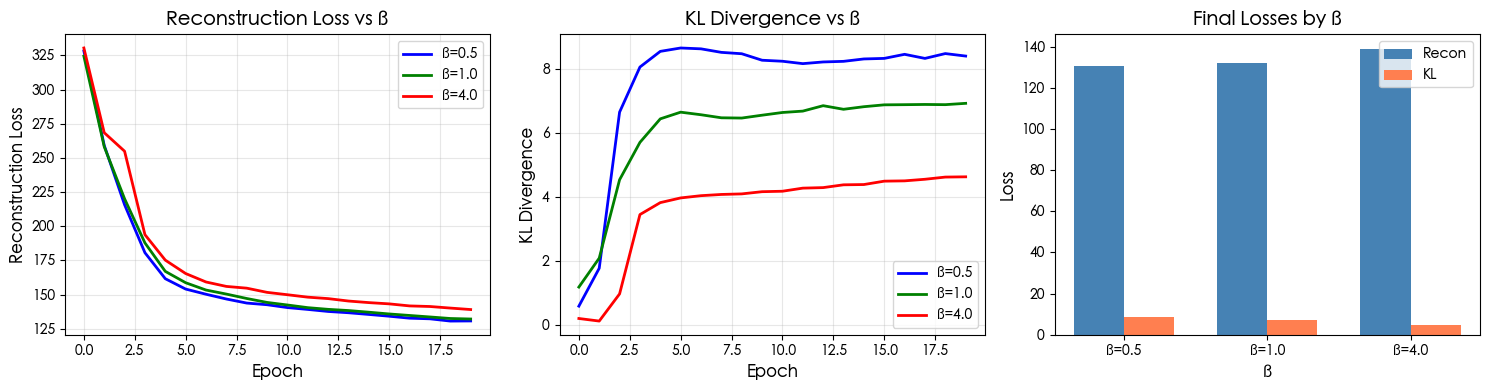

In [14]:
def plot_beta_comparison(results, save_path=None):
    """比較不同 β 值的結果"""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    betas = list(results.keys())
    colors = ['blue', 'green', 'red']
    
    # 重建損失
    for beta, color in zip(betas, colors):
        axes[0].plot(results[beta]['history']['recon'], 
                    label=f'β={beta}', color=color, linewidth=2)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].set_ylabel('Reconstruction Loss', fontsize=12)
    axes[0].set_title('Reconstruction Loss vs β', fontsize=14, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # KL 散度
    for beta, color in zip(betas, colors):
        axes[1].plot(results[beta]['history']['kl'], 
                    label=f'β={beta}', color=color, linewidth=2)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].set_ylabel('KL Divergence', fontsize=12)
    axes[1].set_title('KL Divergence vs β', fontsize=14, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # 最終值比較
    final_recon = [results[b]['history']['recon'][-1] for b in betas]
    final_kl = [results[b]['history']['kl'][-1] for b in betas]
    
    x = np.arange(len(betas))
    width = 0.35
    
    axes[2].bar(x - width/2, final_recon, width, label='Recon', color='steelblue')
    axes[2].bar(x + width/2, final_kl, width, label='KL', color='coral')
    axes[2].set_xlabel('β', fontsize=12)
    axes[2].set_ylabel('Loss', fontsize=12)
    axes[2].set_title('Final Losses by β', fontsize=14, fontweight='bold')
    axes[2].set_xticks(x)
    axes[2].set_xticklabels([f'β={b}' for b in betas])
    axes[2].legend()
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


plot_beta_comparison(beta_results, save_path='beta_comparison.png')

## 13. VAE 架構視覺化

已儲存: vae_architecture.png


<>:17: SyntaxWarning: invalid escape sequence '\p'
<>:17: SyntaxWarning: invalid escape sequence '\p'
/var/folders/4z/9g413kps2l14p9j7pzv9kp8c0000gn/T/ipykernel_98708/4279273469.py:17: SyntaxWarning: invalid escape sequence '\p'
  ax.text(4, 4, 'Encoder\n$q_\phi(z|x)$', ha='center', va='center', fontsize=12)


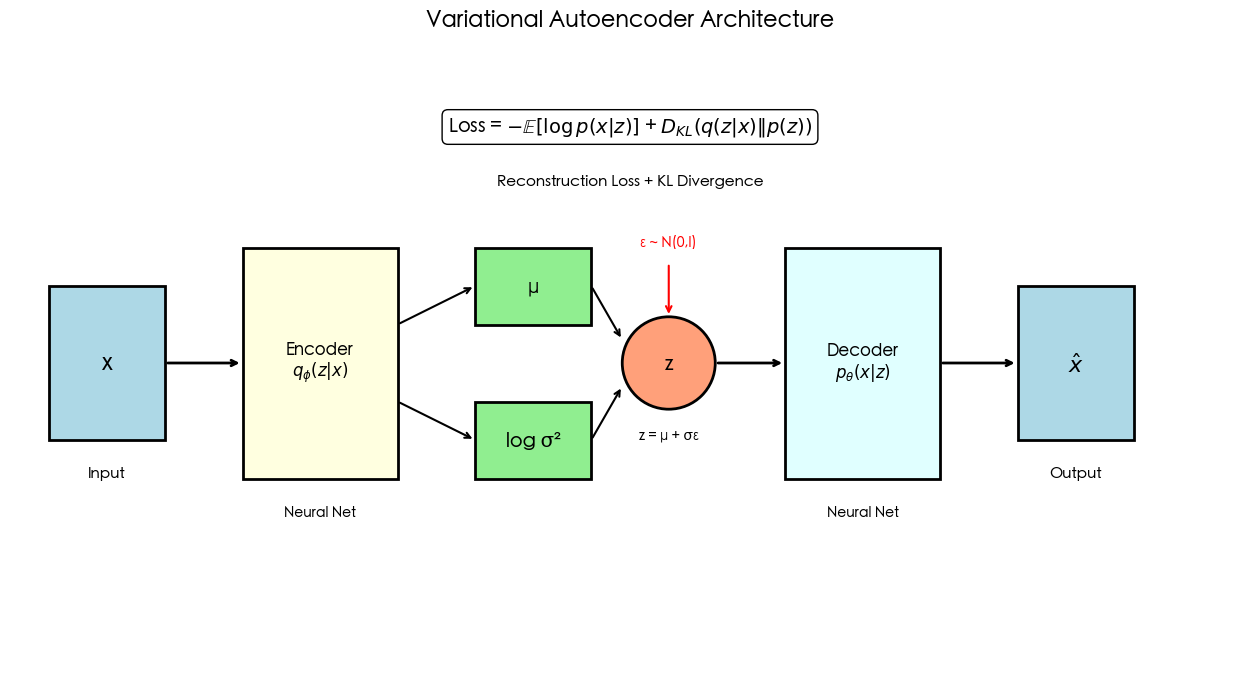

In [15]:
def visualize_vae_architecture(save_path=None):
    """視覺化 VAE 架構"""
    fig, ax = plt.subplots(figsize=(16, 8))
    ax.set_xlim(0, 16)
    ax.set_ylim(0, 8)
    ax.axis('off')
    
    # 輸入
    input_box = plt.Rectangle((0.5, 3), 1.5, 2, color='lightblue', ec='black', linewidth=2)
    ax.add_patch(input_box)
    ax.text(1.25, 4, 'x', ha='center', va='center', fontsize=16, fontweight='bold')
    ax.text(1.25, 2.5, 'Input', ha='center', fontsize=11)
    
    # 編碼器
    encoder_box = plt.Rectangle((3, 2.5), 2, 3, color='lightyellow', ec='black', linewidth=2)
    ax.add_patch(encoder_box)
    ax.text(4, 4, 'Encoder\n$q_\phi(z|x)$', ha='center', va='center', fontsize=12)
    ax.text(4, 2, 'Neural Net', ha='center', fontsize=10)
    
    ax.annotate('', xy=(3, 4), xytext=(2, 4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    # μ 和 log σ²
    mu_box = plt.Rectangle((6, 4.5), 1.5, 1, color='lightgreen', ec='black', linewidth=2)
    ax.add_patch(mu_box)
    ax.text(6.75, 5, 'μ', ha='center', va='center', fontsize=14, fontweight='bold')
    
    logvar_box = plt.Rectangle((6, 2.5), 1.5, 1, color='lightgreen', ec='black', linewidth=2)
    ax.add_patch(logvar_box)
    ax.text(6.75, 3, 'log σ²', ha='center', va='center', fontsize=14, fontweight='bold')
    
    ax.annotate('', xy=(6, 5), xytext=(5, 4.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.annotate('', xy=(6, 3), xytext=(5, 3.5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    # 重參數化
    reparam_circle = plt.Circle((8.5, 4), 0.6, color='lightsalmon', ec='black', linewidth=2)
    ax.add_patch(reparam_circle)
    ax.text(8.5, 4, 'z', ha='center', va='center', fontsize=14, fontweight='bold')
    ax.text(8.5, 3, 'z = μ + σε', ha='center', fontsize=10)
    
    # ε 輸入
    ax.text(8.5, 5.5, 'ε ~ N(0,I)', ha='center', fontsize=10, color='red')
    ax.annotate('', xy=(8.5, 4.6), xytext=(8.5, 5.3),
                arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
    
    ax.annotate('', xy=(7.9, 4.3), xytext=(7.5, 5),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    ax.annotate('', xy=(7.9, 3.7), xytext=(7.5, 3),
                arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
    
    # 解碼器
    decoder_box = plt.Rectangle((10, 2.5), 2, 3, color='lightcyan', ec='black', linewidth=2)
    ax.add_patch(decoder_box)
    ax.text(11, 4, 'Decoder\n$p_\\theta(x|z)$', ha='center', va='center', fontsize=12)
    ax.text(11, 2, 'Neural Net', ha='center', fontsize=10)
    
    ax.annotate('', xy=(10, 4), xytext=(9.1, 4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    # 輸出
    output_box = plt.Rectangle((13, 3), 1.5, 2, color='lightblue', ec='black', linewidth=2)
    ax.add_patch(output_box)
    ax.text(13.75, 4, r'$\hat{x}$', ha='center', va='center', fontsize=16, fontweight='bold')
    ax.text(13.75, 2.5, 'Output', ha='center', fontsize=11)
    
    ax.annotate('', xy=(13, 4), xytext=(12, 4),
                arrowprops=dict(arrowstyle='->', color='black', lw=2))
    
    # 損失函數
    ax.text(8, 7, r'Loss = $-\mathbb{E}[\log p(x|z)]$ + $D_{KL}(q(z|x) \| p(z))$',
            ha='center', fontsize=14, 
            bbox=dict(boxstyle='round', facecolor='white', edgecolor='black'))
    ax.text(8, 6.3, 'Reconstruction Loss + KL Divergence', ha='center', fontsize=11)
    
    ax.set_title('Variational Autoencoder Architecture', fontsize=16, fontweight='bold', pad=20)
    
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight', facecolor='white')
        print(f"已儲存: {save_path}")
    
    plt.show()


visualize_vae_architecture(save_path='vae_architecture.png')

## 14. 總結

### VAE 核心要點

1. **機率潛在空間**：
   - 編碼器輸出分布參數 $(\mu, \log \sigma^2)$ 而非固定向量
   - 潛在空間具有連續性和可解釋性

2. **重參數化技巧**：
   $$z = \mu + \sigma \odot \epsilon, \quad \epsilon \sim \mathcal{N}(0, I)$$
   - 使採樣操作可微分
   - 梯度可以流經 $\mu$ 和 $\sigma$

3. **ELBO 損失**：
   $$\mathcal{L} = \text{Recon} + \text{KL}$$
   - 重建項：確保重建品質
   - KL 項：正則化潛在空間

4. **應用**：
   - 圖像生成
   - 異常檢測
   - 資料增強
   - 表示學習

In [16]:
# 總結
print("=" * 60)
print("第十七章：變分自編碼器 (VAE) 實作完成！")
print("=" * 60)
print("\n生成的檔案:")
print("  - training_samples.png: 訓練資料樣本")
print("  - training_curves.png: 訓練曲線")
print("  - reconstruction.png: 重建品質")
print("  - latent_space.png: 潛在空間視覺化")
print("  - generated_samples.png: 生成樣本")
print("  - interpolation.png: 潛在空間插值")
print("  - latent_grid.png: 潛在空間網格")
print("  - reparameterization.png: 重參數化視覺化")
print("  - beta_comparison.png: β-VAE 比較")
print("  - vae_architecture.png: VAE 架構圖")
print("\n核心公式:")
print("  ELBO = E[log p(x|z)] - KL(q(z|x) || p(z))")
print("  重參數化: z = μ + σ ⊙ ε, ε ~ N(0,I)")

第十七章：變分自編碼器 (VAE) 實作完成！

生成的檔案:
  - training_samples.png: 訓練資料樣本
  - training_curves.png: 訓練曲線
  - reconstruction.png: 重建品質
  - latent_space.png: 潛在空間視覺化
  - generated_samples.png: 生成樣本
  - interpolation.png: 潛在空間插值
  - latent_grid.png: 潛在空間網格
  - reparameterization.png: 重參數化視覺化
  - beta_comparison.png: β-VAE 比較
  - vae_architecture.png: VAE 架構圖

核心公式:
  ELBO = E[log p(x|z)] - KL(q(z|x) || p(z))
  重參數化: z = μ + σ ⊙ ε, ε ~ N(0,I)
